In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from google.colab import files
import io

# 1. Performance Indicators
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

def da(y_true, y_pred):
    # Directional Accuracy (Precisión Direccional)
    diff_true = np.diff(y_true)
    diff_pred = np.diff(y_pred)
    return 100 * np.mean(np.sign(diff_true) == np.sign(diff_pred))

# 2. FMFRA-DLF
print("==================================================")
print("STEP 1: Load the Forecasting test .csv")
print("==================================================")
uploaded_preds = files.upload()

nombre_archivo_preds = list(uploaded_preds.keys())[0]
df_preds = pd.read_csv(io.BytesIO(uploaded_preds[nombre_archivo_preds]))
print("\n[OK] ")

# 3.  Blind Test
print("\n==================================================")
print("STEP 2: Load the test")
print("Example: HOUSTON_test.csv, MATAMOROS_test.csv, etc.")
print("==================================================")
uploaded_tests = files.upload()
print("\n[OK]")

PASO 1: Sube el archivo 'Pronosticos_FMFRA_Prueba.csv'


Saving Pronosticos_FMFRA_Prueba.csv to Pronosticos_FMFRA_Prueba.csv

[OK] Pronósticos cargados exitosamente.

PASO 2: Sube los 4 archivos reales de prueba simultáneamente
Ejemplo: HOUSTON_test.csv, MATAMOROS_test.csv, etc.


Saving HOUSTON_test.csv to HOUSTON_test.csv
Saving MATAMOROS_test.csv to MATAMOROS_test.csv
Saving MIAMI_test.csv to MIAMI_test.csv
Saving TAMPICO_test.csv to TAMPICO_test.csv

[OK] Archivos de prueba cargados.


--- Generando Evaluación de Conjunto de Prueba Ciego ---


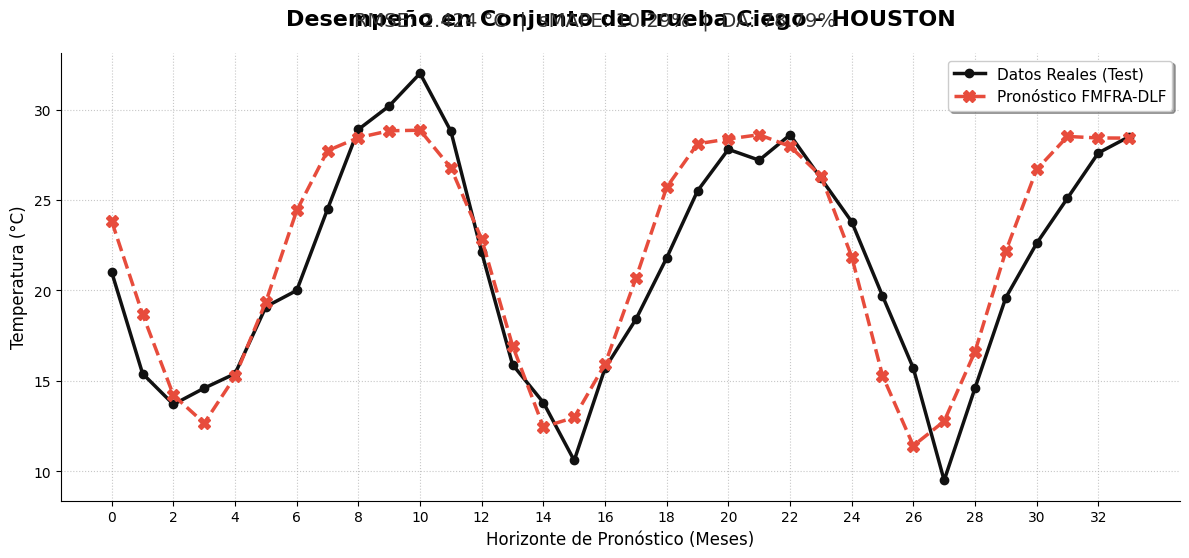

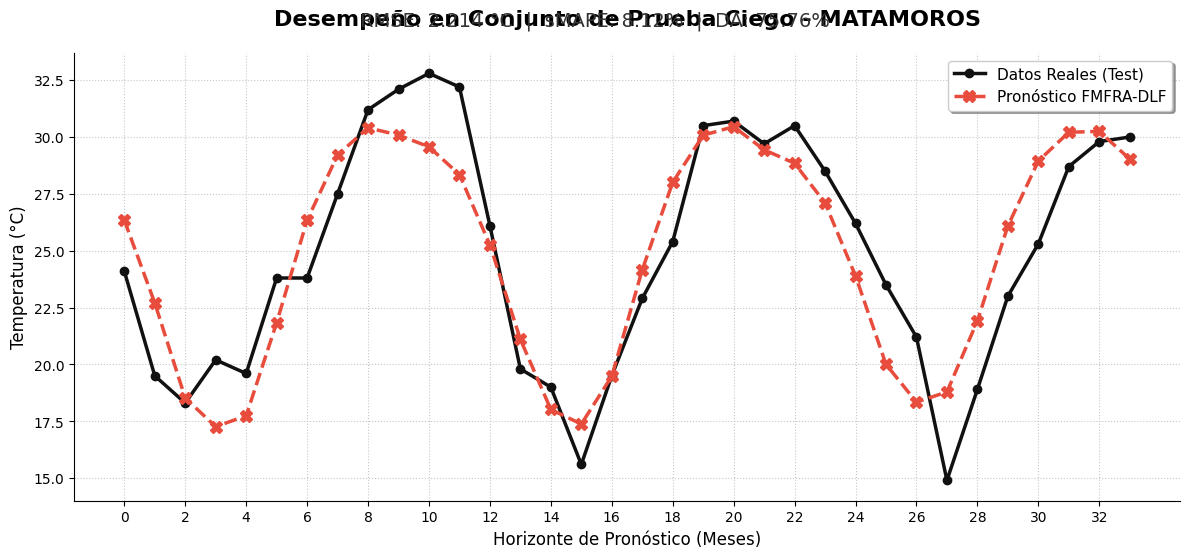

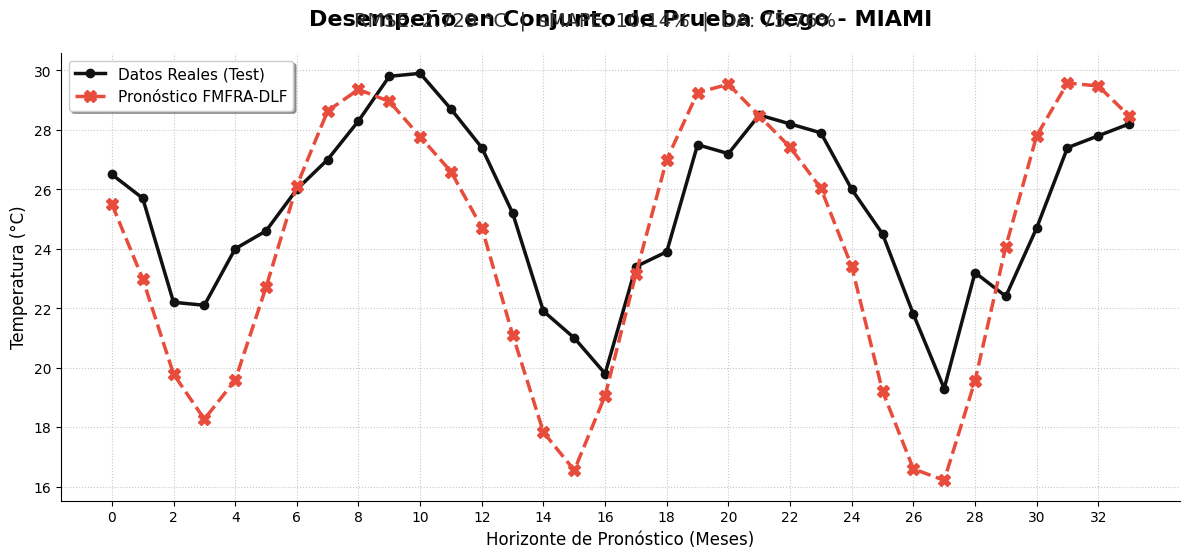

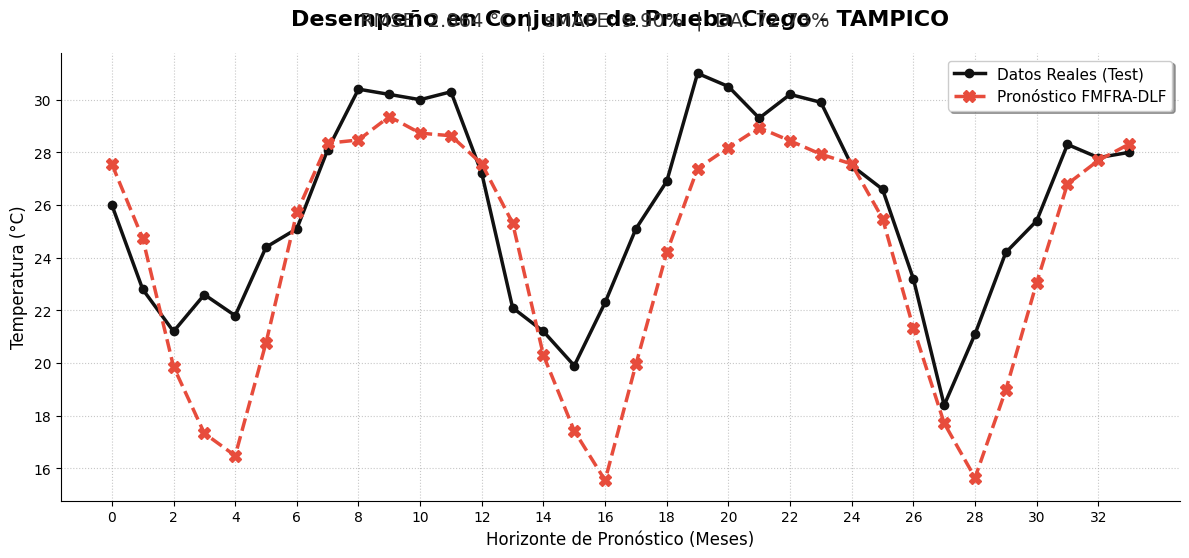


RESUMEN ESTADÍSTICO PARA EL ARTÍCULO (Q2):


,Ciudad,RMSE,sMAPE (%),DA (%)
0,HOUSTON,2.424,10.29,78.79
1,MATAMOROS,2.214,8.12,75.76
2,MIAMI,2.729,10.14,75.76
3,TAMPICO,2.864,9.90,72.73


In [2]:
# =====================================================================
# EVALUACIÓN FINAL DE DESEMPEÑO Y GRÁFICAS INDIVIDUALES
# =====================================================================

ciudades_pronosticadas = df_preds['Ciudad'].unique()
resultados_finales = []

for city in ciudades_pronosticadas:
    # 1. Extraer los pronósticos de la ciudad (ordenados por Paso)
    city_preds = df_preds[df_preds['Ciudad'] == city].sort_values('Paso')['Pronostico_FMFRA'].values
    horizonte = len(city_preds)

    # 2. Buscar el archivo de prueba correspondiente
    # Manejo de nombres flexibles (ej. HOUSTON_test.csv o houston_test.csv)
    test_filename = None
    for filename in uploaded_tests.keys():
        if city.lower() in filename.lower():
            test_filename = filename
            break

    if test_filename is None:
        print(f"[ADVERTENCIA] No se subió un archivo de prueba para {city}. Saltando...")
        continue

    # 3. Extraer la serie real del archivo CSV
    df_test = pd.read_csv(io.BytesIO(uploaded_tests[test_filename]), encoding='latin1')
    y_test_real = df_test.iloc[:, 1:].values.flatten()
    y_test_real = y_test_real[~np.isnan(y_test_real)][:horizonte] # Tomamos los 34 exactos

    # 4. Cálculo de Métricas (Evaluación a ciegas)
    rmse_test = np.sqrt(mean_squared_error(y_test_real, city_preds))
    smape_test = smape(y_test_real, city_preds)
    da_test = da(y_test_real, city_preds)

    resultados_finales.append({
        'Ciudad': city,
        'RMSE': round(rmse_test, 3),
        'sMAPE (%)': round(smape_test, 2),
        'DA (%)': round(da_test, 2)
    })

    # 5. Despliegue de la Gráfica Científica Individual
    plt.figure(figsize=(12, 6))

    # Curvas
    plt.plot(y_test_real, label='Datos Reales (Test)', color='#111111', marker='o', linewidth=2.5, markersize=6)
    plt.plot(city_preds, label='Pronóstico FMFRA-DLF', color='#E74C3C', marker='X', linestyle='--', linewidth=2.5, markersize=8)

    # Diseño de la gráfica para artículo
    plt.title(f'Desempeño en Conjunto de Prueba Ciego - {city}', fontsize=16, fontweight='bold', pad=20)
    plt.suptitle(f'RMSE: {rmse_test:.3f} °C  |  sMAPE: {smape_test:.2f}%  |  DA: {da_test:.2f}%',
                 fontsize=14, color='#333333', y=0.92)

    plt.xlabel('Horizonte de Pronóstico (Meses)', fontsize=12)
    plt.ylabel('Temperatura (°C)', fontsize=12)
    plt.xticks(np.arange(0, horizonte, step=2)) # Marcas en el eje X cada 2 meses
    plt.legend(loc='best', fontsize=11, frameon=True, shadow=True)
    plt.grid(True, linestyle=':', alpha=0.7)

    # Bordes más limpios
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()
    plt.subplots_adjust(top=0.85) # Espacio para el doble título
    plt.show()

# =====================================================================
# TABLA RESUMEN FINAL
# =====================================================================
print("\n==================================================")
print("RESUMEN ESTADÍSTICO PARA EL ARTÍCULO (Q2):")
print("==================================================")
df_resumen = pd.DataFrame(resultados_finales)
display(df_resumen)

# Opcional: exportar este resumen a CSV
df_resumen.to_csv('Evaluacion_Final_Metricas.csv', index=False)